In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, auc, classification_report, 
                             confusion_matrix, precision_recall_curve, f1_score, 
                             accuracy_score, precision_score, recall_score)
from sklearn.inspection import permutation_importance
import json
from datetime import datetime

# Configuración de visualización
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Cambiar al directorio del proyecto
os.chdir('c:\\Users\\robin\\dev\\01_LEADSCORING')

print('✓ Librerías importadas correctamente')

✓ Librerías importadas correctamente


# FASE 7: MODELIZACIÓN CON REGRESIÓN LOGÍSTICA
## Agente A_07_Modelizador (Simplificado)

**Objetivo:** Entrenar y optimizar Regresión Logística para clasificación binaria
- Algoritmo: Logistic Regression con L2 regularization
- Método: RandomizedSearchCV con validación cruzada estratificada
- Métricas: RECALL, Precision, F1, AUC-ROC
- Output: Modelo entrenado + configuración ganadora en JSON

### Contexto Actual
- **Dataset:** 05_train_tablon_preseleccion.pkl (6,279 registros × 27 columnas)
- **Target:** compra (0=No, 1=Sí)
- **Distribución:** 37.2% conversión
- **Método:** Sin balanceo de clases (distribución natural)

## PASO 1: Carga del Dataset Preseleccionado

In [2]:
# Cargar dataset preseleccionado
ruta_datos = '02_datos/03_Entrenamiento/05_train_tablon_preseleccion.pkl'
df_modelo = pd.read_pickle(ruta_datos)

print(f'✓ Dataset cargado: {df_modelo.shape[0]} registros × {df_modelo.shape[1]} columnas')
print(f'\nDistribución del target (compra):')
print(df_modelo['compra'].value_counts())
print(f'\nProporción:')
print(f'  - Clase 0 (No compró): {(df_modelo["compra"]==0).sum() / len(df_modelo) * 100:.1f}%')
print(f'  - Clase 1 (Compró): {(df_modelo["compra"]==1).sum() / len(df_modelo) * 100:.1f}%')
print(f'\nNulos totales: {df_modelo.isnull().sum().sum()}')
print(f'\nVariables: {list(df_modelo.columns[:-1][:5])} ... ({df_modelo.shape[1]-1} variables totales)')

✓ Dataset cargado: 6279 registros × 27 columnas

Distribución del target (compra):
compra
0    3944
1    2335
Name: count, dtype: int64

Proporción:
  - Clase 0 (No compró): 62.8%
  - Clase 1 (Compró): 37.2%

Nulos totales: 0

Variables: ['visitas_total_mms', 'tiempo_en_site_total_mms', 'paginas_vistas_visita_mms', 'usuario_nuevo', 'origen_Landing Page Submission'] ... (26 variables totales)


## PASO 2: Preparación de Features y Target

In [3]:
# Separar features y target
X = df_modelo.drop('compra', axis=1)
y = df_modelo['compra']

# Guardar nombres de las variables para interpretabilidad posterior
feature_names = X.columns.tolist()

# Escalar features para LogisticRegression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

print(f'✓ Features (X): {X_scaled.shape}')
print(f'✓ Target (y): {y.shape}')
print(f'\n✓ Variables escaladas con StandardScaler')
print(f'  - Rango: [{X_scaled.values.min():.3f}, {X_scaled.values.max():.3f}]')
print(f'\n✓ Distribución del target:')
print(f'  - Clase 0: {(y==0).sum()} registros ({(y==0).sum() / len(y) * 100:.1f}%)')
print(f'  - Clase 1: {(y==1).sum()} registros ({(y==1).sum() / len(y) * 100:.1f}%)')

✓ Features (X): (6279, 26)
✓ Target (y): (6279,)

✓ Variables escaladas con StandardScaler
  - Rango: [-1.209, 56.022]

✓ Distribución del target:
  - Clase 0: 3944 registros (62.8%)
  - Clase 1: 2335 registros (37.2%)


## PASO 3: Configuración de Validación Cruzada

In [4]:
# Configurar StratifiedKFold con 5 folds (rápido y robusto)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'✓ Estrategia de validación cruzada configurada')
print(f'  - Tipo: StratifiedKFold')
print(f'  - Número de folds: 5')
print(f'  - Shuffle: True')
print(f'  - Random state: 42')

# Verificar distribución en cada fold
print(f'\n✓ Distribución del target en cada fold:')
for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_scaled, y)):
    y_fold = y.iloc[val_idx]
    class_0_pct = (y_fold == 0).sum() / len(y_fold) * 100
    class_1_pct = (y_fold == 1).sum() / len(y_fold) * 100
    print(f'  Fold {fold_idx+1}: Clase 0={class_0_pct:.1f}% | Clase 1={class_1_pct:.1f}%')

✓ Estrategia de validación cruzada configurada
  - Tipo: StratifiedKFold
  - Número de folds: 5
  - Shuffle: True
  - Random state: 42

✓ Distribución del target en cada fold:
  Fold 1: Clase 0=62.8% | Clase 1=37.2%
  Fold 2: Clase 0=62.8% | Clase 1=37.2%
  Fold 3: Clase 0=62.8% | Clase 1=37.2%
  Fold 4: Clase 0=62.8% | Clase 1=37.2%
  Fold 5: Clase 0=62.8% | Clase 1=37.2%


## PASO 4: Búsqueda de Hiperparámetros para Logistic Regression

In [5]:
# Definir espacio de hiperparámetros para LogisticRegression
param_dist = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    'max_iter': [500, 1000, 2000],
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced'],
    'tol': [1e-4, 1e-3, 1e-2]
}

# Crear modelo base
lr_base = LogisticRegression(random_state=42, n_jobs=-1)

# Configurar RandomizedSearchCV
print('🔄 Ejecutando RandomizedSearchCV para LogisticRegression...')
print(f'  - Métrica de optimización: recall_weighted')
print(f'  - Número de iteraciones: 30')
print(f'  - CV: StratifiedKFold(5)')

randomized_search = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring='recall_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Ejecutar búsqueda
randomized_search.fit(X_scaled, y)

print(f'\n✓ Búsqueda completada')
print(f'\n📊 Mejores parámetros encontrados:')
for param, value in randomized_search.best_params_.items():
    print(f'  - {param}: {value}')

print(f'\n📈 Mejor score (recall_weighted): {randomized_search.best_score_:.4f}')

# Obtener modelo ganador
best_model = randomized_search.best_estimator_

print(f'\n✓ Modelo ganador configurado y entrenado')

🔄 Ejecutando RandomizedSearchCV para LogisticRegression...
  - Métrica de optimización: recall_weighted
  - Número de iteraciones: 30
  - CV: StratifiedKFold(5)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Búsqueda completada

📊 Mejores parámetros encontrados:
  - tol: 0.0001
  - solver: lbfgs
  - penalty: l2
  - max_iter: 1000
  - class_weight: None
  - C: 100.0

📈 Mejor score (recall_weighted): 0.8178

✓ Modelo ganador configurado y entrenado


## PASO 5: Evaluación del Modelo en Validación Cruzada

In [6]:
# Calcular múltiples métricas en CV
metrics = ['recall_weighted', 'precision_weighted', 'f1_weighted', 'roc_auc', 'accuracy']
results = {}

for metric in metrics:
    scores = cross_val_score(best_model, X_scaled, y, cv=cv_strategy, scoring=metric, n_jobs=-1)
    results[metric] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }

print('✓ Evaluación en Validación Cruzada (5 folds):')
print('\n' + '='*70)
print(f'{"Métrica":<20} {"Media":<15} {"Std":<15} {"Min-Max"}')
print('='*70)

for metric, data in results.items():
    print(f'{metric:<20} {data["mean"]:<15.4f} {data["std"]:<15.4f} {data["scores"].min():.4f} - {data["scores"].max():.4f}')

print('='*70)

print(f'\n✓ Métricas de validación cruzada calculadas')

✓ Evaluación en Validación Cruzada (5 folds):

Métrica              Media           Std             Min-Max
recall_weighted      0.8178          0.0062          0.8089 - 0.8240
precision_weighted   0.8161          0.0064          0.8069 - 0.8228
f1_weighted          0.8154          0.0057          0.8072 - 0.8209
roc_auc              0.8864          0.0031          0.8818 - 0.8895
accuracy             0.8178          0.0062          0.8089 - 0.8240

✓ Métricas de validación cruzada calculadas


## PASO 6: Importancia de Variables

In [7]:
# Calcular coeficientes de LogisticRegression
coefficients = best_model.coef_[0]
coef_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coefficients,
    'abs_coeficiente': np.abs(coefficients)
}).sort_values('abs_coeficiente', ascending=False)

print('✓ Top 10 variables por coeficiente (magnitud):')
print(coef_df.head(10).to_string(index=False))

# Calcular Permutation Importance
print('\n🔄 Calculando Permutation Importance...')
perm_importance = permutation_importance(best_model, X_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'variable': feature_names,
    'importancia': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importancia', ascending=False)

print('\n✓ Top 10 variables por Permutation Importance:')
print(perm_df.head(10).to_string(index=False))

✓ Top 10 variables por coeficiente (magnitud):
                       variable  coeficiente  abs_coeficiente
       tiempo_en_site_total_mms        1.096            1.096
         ocupacion_Not Provided       -0.731            0.731
         ult_actividad_SMS Sent        0.582            0.582
 ocupacion_Working Professional        0.578            0.578
          fuente_Direct Traffic       -0.546            0.546
           origen_Lead Add Form        0.467            0.467
ult_actividad_Chat Conversation       -0.441            0.441
    ult_actividad_Email Bounced       -0.399            0.399
                  fuente_Google       -0.390            0.390
 origen_Landing Page Submission       -0.367            0.367

🔄 Calculando Permutation Importance...

✓ Top 10 variables por Permutation Importance:
                      variable  importancia   std
      tiempo_en_site_total_mms        0.108 0.003
        ult_actividad_SMS Sent        0.030 0.003
        ocupacion_Not Provided   

## PASO 7: Entrenamiento Final y Predicciones en Todo el Dataset

In [8]:
# Entrenar modelo final en TODO el dataset
print('🔄 Entrenando modelo final en todo el dataset...')
final_model = LogisticRegression(**randomized_search.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X_scaled, y)

# Hacer predicciones
y_pred_proba = final_model.predict_proba(X_scaled)[:, 1]
y_pred = final_model.predict(X_scaled)

print('✓ Modelo final entrenado en todo el dataset')
print(f'✓ Predicciones generadas: {len(y_pred)} muestras')

🔄 Entrenando modelo final en todo el dataset...
✓ Modelo final entrenado en todo el dataset
✓ Predicciones generadas: 6279 muestras


## PASO 8: Cálculo de AUC y Métricas Detalladas

In [9]:
# Calcular AUC en el dataset completo
auc_score = roc_auc_score(y, y_pred_proba)

print('✅ MÉTRICA PRINCIPAL: AUC-ROC')
print(f'{"="*70}')
print(f'AUC-ROC Score: {auc_score:.4f}')
print(f'{"="*70}')

# Otras métricas en dataset completo
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f'\n✓ Métricas adicionales (threshold=0.5):')
print(f'  - Accuracy:  {accuracy:.4f}')
print(f'  - Precision: {precision:.4f}')
print(f'  - Recall:    {recall:.4f}')
print(f'  - F1-Score:  {f1:.4f}')

# Matriz de confusión
cm = confusion_matrix(y, y_pred)
print(f'\n✓ Matriz de Confusión:')
print(f'  TN={cm[0,0]}, FP={cm[0,1]}')
print(f'  FN={cm[1,0]}, TP={cm[1,1]}')

# Reporte de clasificación
print(f'\n✓ Reporte de Clasificación Detallado:')
print(classification_report(y, y_pred, target_names=['No Compró (0)', 'Compró (1)']))

✅ MÉTRICA PRINCIPAL: AUC-ROC
AUC-ROC Score: 0.8898

✓ Métricas adicionales (threshold=0.5):
  - Accuracy:  0.8200
  - Precision: 0.7901
  - Recall:    0.7028
  - F1-Score:  0.7439

✓ Matriz de Confusión:
  TN=3508, FP=436
  FN=694, TP=1641

✓ Reporte de Clasificación Detallado:
               precision    recall  f1-score   support

No Compró (0)       0.83      0.89      0.86      3944
   Compró (1)       0.79      0.70      0.74      2335

     accuracy                           0.82      6279
    macro avg       0.81      0.80      0.80      6279
 weighted avg       0.82      0.82      0.82      6279



## PASO 9: Curva ROC y Visualizaciones

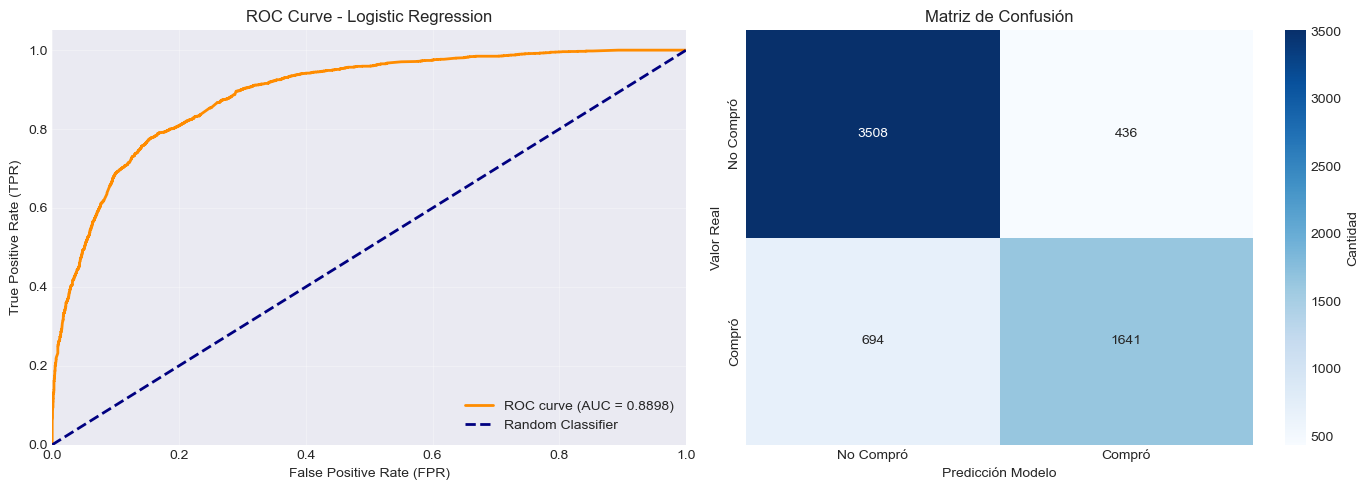

✓ Visualizaciones guardadas en 06_resultados/Modelizacion/roc_curve.png


In [10]:
# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)

# Crear visualización de la curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curva ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve - Logistic Regression')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(alpha=0.3)

# Gráfico 2: Matriz de Confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Compró', 'Compró'],
            yticklabels=['No Compró', 'Compró'],
            cbar_kws={'label': 'Cantidad'})
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Predicción Modelo')
axes[1].set_title('Matriz de Confusión')

plt.tight_layout()
plt.savefig('06_resultados/Modelizacion/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Visualizaciones guardadas en 06_resultados/Modelizacion/roc_curve.png')

## PASO 10: Análisis de Umbrales de Decisión

In [11]:
# Analizar diferentes umbrales de decisión
umbrales_test = [0.3, 0.4, 0.5, 0.6, 0.7]
resultados_umbrales = []

print('✓ Análisis de diferentes umbrales de decisión:')
print(f'\n{"Umbral":<10} {"Precision":<12} {"Recall":<12} {"F1-Score":<12} {"Accuracy":<12}')
print('='*50)

for umbral in umbrales_test:
    y_pred_custom = (y_pred_proba >= umbral).astype(int)
    prec = precision_score(y, y_pred_custom, zero_division=0)
    rec = recall_score(y, y_pred_custom, zero_division=0)
    f1 = f1_score(y, y_pred_custom, zero_division=0)
    acc = accuracy_score(y, y_pred_custom)

    resultados_umbrales.append({
        'umbral': umbral,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'accuracy': acc
    })

    print(f'{umbral:<10.1f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {acc:<12.4f}')

print('='*50)
print('\n✓ Análisis completado')

# Guardar resultados de umbrales
umbral_df = pd.DataFrame(resultados_umbrales)
ruta_umbrales = '06_resultados/Modelizacion/analisis_umbrales.csv'
umbral_df.to_csv(ruta_umbrales, index=False)
print(f'\n✓ Resultados guardados en: {ruta_umbrales}')

✓ Análisis de diferentes umbrales de decisión:

Umbral     Precision    Recall       F1-Score     Accuracy    
0.3        0.6798       0.8338       0.7490       0.7922      
0.4        0.7437       0.7790       0.7609       0.8180      
0.5        0.7901       0.7028       0.7439       0.8200      
0.6        0.8286       0.5961       0.6934       0.8039      
0.7        0.8520       0.5105       0.6385       0.7850      

✓ Análisis completado

✓ Resultados guardados en: 06_resultados/Modelizacion/analisis_umbrales.csv


In [12]:
# Crear estructura de configuración completa
config_final = {
    'timestamp': datetime.now().isoformat(),
    'algoritmo': 'LogisticRegression',
    'tipo_problema': 'clasificacion_binaria',
    'dataset': {
        'ruta': '02_datos/03_Entrenamiento/05_train_tablon_preseleccion.pkl',
        'registros': len(df_modelo),
        'variables': len(feature_names),
        'tasa_positivos': float((y==1).sum() / len(y))
    },
    'validacion': {
        'estrategia': 'StratifiedKFold',
        'n_folds': 5,
        'metrica_optimizacion': 'recall_weighted',
        'shuffle': True,
        'random_state': 42
    },
    'mejores_parametros': {str(k): str(v) for k, v in randomized_search.best_params_.items()},
    'metricas_cv': {
        metric: {
            'media': float(data['mean']),
            'std': float(data['std']),
            'min': float(data['scores'].min()),
            'max': float(data['scores'].max())
        }
        for metric, data in results.items()
    },
    'variables_top10_coeficientes': coef_df.head(10)[['variable', 'coeficiente']].to_dict('records'),
    'variables_top10_permutation': perm_df.head(10)[['variable', 'importancia']].to_dict('records')
}

# Crear directorio de resultados
os.makedirs('06_resultados/Modelizacion', exist_ok=True)

# Guardar configuración en JSON
ruta_config = '06_resultados/Modelizacion/config_mejor_modelo.json'
with open(ruta_config, 'w') as f:
    json.dump(config_final, f, indent=2)

print(f'✓ Configuración guardada en: {ruta_config}')

# Guardar resultados detallados de CV
ruta_resultados = '06_resultados/Modelizacion/resultados_cv.csv'
resultados_cv_df = pd.DataFrame(randomized_search.cv_results_)
resultados_cv_df.to_csv(ruta_resultados, index=False)

print(f'✓ Resultados detallados de CV guardados en: {ruta_resultados}')

✓ Configuración guardada en: 06_resultados/Modelizacion/config_mejor_modelo.json
✓ Resultados detallados de CV guardados en: 06_resultados/Modelizacion/resultados_cv.csv
